In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import time

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [2]:
# Константы архитектуры 
INPUT_DIM = 784        
HIDDEN_DIM = 400       
LATENT_DIM = 20        

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.fc_mu = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.fc_logvar = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        # Decoder
        self.fc3 = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.fc4 = nn.Linear(HIDDEN_DIM, INPUT_DIM)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.tanh(self.fc4(h3)) 

    def forward(self, x):
        x = x.view(-1, INPUT_DIM)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

model = VAE().to(device)
print("Модель VAE инициализирована.")

Модель VAE инициализирована.


In [3]:
# Загрузка Fashion-MNIST с нормализацией в диапазон [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
])

train_dataset = torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Новая функция потерь для VAE 
def loss_function_vae(recon_x, x, mu, logvar):
    MSE = F.mse_loss(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

optimizer_vae = optim.Adam(model.parameters(), lr=1e-3)

print("Обучение VAE...")
model.train()
for epoch in range(1, 21):
    train_loss = 0
    for data, _ in train_loader:
        data = data.to(device)
        optimizer_vae.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function_vae(recon_batch, data, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        train_loss += loss.item()
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch}: Average loss: {train_loss / len(train_loader.dataset):.4f}')

print("Обучение VAE завершено.")

Обучение VAE...
Epoch 1: Average loss: 101.7198
Epoch 5: Average loss: 67.6677
Epoch 10: Average loss: 64.3050
Epoch 15: Average loss: 62.8019
Epoch 20: Average loss: 61.8593
Обучение VAE завершено.


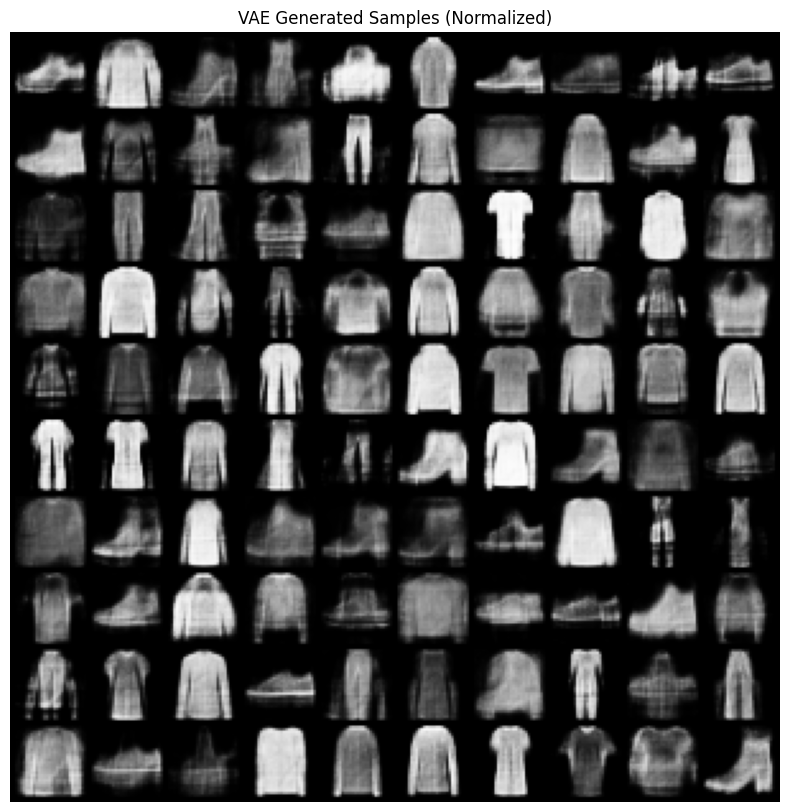

Saved 200 VAE samples to evaluation/vae_samples.pt


In [4]:
def save_vae_samples(model, n_samples=200, folder="evaluation"):
    if not os.path.exists(folder):
        os.makedirs(folder)
        
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, 20).to(device) 
        samples = model.decode(z).cpu()
        samples = samples.view(-1, 1, 28, 28)
        
        # Перенос из [-1, 1] обратно в [0, 1] 
        samples = (samples + 1) / 2
        samples = torch.clamp(samples, 0, 1)
        
        torch.save(samples, f"{folder}/vae_samples.pt")
        
        grid = torchvision.utils.make_grid(samples[:100], nrow=10)
        plt.figure(figsize=(10, 10))
        plt.imshow(grid.permute(1, 2, 0), cmap='gray')
        plt.title(f"VAE Generated Samples (Normalized)")
        plt.axis('off')
        plt.show()
    
    print(f"Saved {n_samples} VAE samples to {folder}/vae_samples.pt")

save_vae_samples(model)

In [5]:
# Архитектура классификатора 
class JudgeCNN(nn.Module):
    def __init__(self):
        super(JudgeCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 28x28 -> 14x14
        x = self.pool(F.relu(self.conv2(x))) # 14x14 -> 7x7
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Инициализация и обучение
judge_model = JudgeCNN().to(device)
judge_optimizer = optim.Adam(judge_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("Обучение классификатора...")

judge_model.train()
for epoch in range(5): 
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        judge_optimizer.zero_grad()
        output = judge_model(data)
        loss = criterion(output, target)
        loss.backward()
        judge_optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# Проверка точности 
judge_model.eval()
correct = 0
with torch.no_grad():
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        output = judge_model(data)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

print(f"\nТочность на реальных данных: {100. * correct / len(train_loader.dataset):.2f}%")

Обучение классификатора...
Epoch 1, Loss: 0.5142
Epoch 2, Loss: 0.3255
Epoch 3, Loss: 0.2809
Epoch 4, Loss: 0.2521
Epoch 5, Loss: 0.2289

Точность на реальных данных: 93.56%


In [6]:
# Настройки диффузии 
T = 500
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def get_index_from_list(vals, t, x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1, t) 
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

# Архитектура Heavy Unet 
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResnetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.relu = nn.SiLU()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t):
        h = self.relu(self.norm1(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.relu(self.norm2(self.conv2(h)))
        return h + self.shortcut(x)

class HeavyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.time_mlp = nn.Sequential(SinusoidalPositionEmbeddings(32), nn.Linear(32, 64), nn.SiLU())
        self.conv0 = nn.Conv2d(1, 64, 3, padding=1)
        
        # Encoder 
        self.down1 = ResnetBlock(64, 128, 64)  # Выход: 128 каналов
        self.down2 = ResnetBlock(128, 256, 64) # Выход: 256 каналов
        self.pool = nn.MaxPool2d(2)
        
        # Decoder 
        # Вход 512 каналов
        self.up1 = ResnetBlock(512, 128, 64)
        # Вход 256 каналов
        self.up2 = ResnetBlock(256, 64, 64)
        
        self.final_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        
        # Начальный слой
        x = self.conv0(x) # 64
        
        # Энкодер
        h1 = self.down1(x, t)  # 128, 28x28
        p1 = self.pool(h1)     # 128, 14x14
        h2 = self.down2(p1, t) # 256, 14x14
        p2 = self.pool(h2)     # 256, 7x7
        
        # Декодер
        u1 = F.interpolate(p2, scale_factor=2, mode='bilinear', align_corners=True) 
        u1 = torch.cat([u1, h2], dim=1) 
        u1 = self.up1(u1, t)           
        
        u2 = F.interpolate(u1, scale_factor=2, mode='bilinear', align_corners=True) 
        u2 = torch.cat([u2, h1], dim=1)
        u2 = self.up2(u2, t)         
        
        return self.final_conv(u2)

diffusion_model = HeavyUNet().to(device)
print(f"Диффузионная UNet создана. Количество параметров:{sum(p.numel() for p in diffusion_model.parameters())}")

Диффузионная UNet создана. Количество параметров:2194689


In [7]:
# Функция прямого процесса (добавление шума)
def forward_diffusion_sample(x_0, t, device=device):
    """Принимает чистое изображение и шаг t, возвращает зашумленное изображение"""
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(torch.sqrt(alphas_cumprod), t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        torch.sqrt(1. - alphas_cumprod), t, x_0.shape
    )
    # Формула: x_t = sqrt(alpha_cumprod)*x_0 + sqrt(1-alpha_cumprod)*noise
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)

# Функция вычисления потерь
def get_loss(model, x_0, t):
    x_noisy, noise = forward_diffusion_sample(x_0, t)
    noise_pred = model(x_noisy, t)
    return F.mse_loss(noise, noise_pred)

# Настройка обучения для HeavyUNet
# Понижаем lr до 2e-4 
optimizer_diff = optim.Adam(diffusion_model.parameters(), lr=2e-4)
epochs = 50 

print(f"Начинаем обучение DDPM на {device}...")
start_time = time.time()

diffusion_model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for step, batch in enumerate(train_loader):
        optimizer_diff.zero_grad()
        
        x_0 = batch[0].to(device)
        batch_size = x_0.shape[0]
        t = torch.randint(0, T, (batch_size,), device=device).long()
        
        loss = get_loss(diffusion_model, x_0, t)
        loss.backward()
        optimizer_diff.step()
        
        epoch_loss += loss.item()
        
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss / len(train_loader):.5f}")

end_time = time.time()
print(f"Обучение завершено за {(end_time - start_time)/60:.2f} минут.")

Начинаем обучение DDPM на mps...
Epoch 1/50 | Loss: 0.15689
Epoch 5/50 | Loss: 0.06946
Epoch 10/50 | Loss: 0.06104
Epoch 15/50 | Loss: 0.05819
Epoch 20/50 | Loss: 0.05632
Epoch 25/50 | Loss: 0.05484
Epoch 30/50 | Loss: 0.05404
Epoch 35/50 | Loss: 0.05387
Epoch 40/50 | Loss: 0.05240
Epoch 45/50 | Loss: 0.05256
Epoch 50/50 | Loss: 0.05246
Обучение завершено за 76.16 минут.


Начинаем процесс обратной диффузии для 200 образцов...
Шаг 500/500 завершен...
Шаг 400/500 завершен...
Шаг 300/500 завершен...
Шаг 200/500 завершен...
Шаг 100/500 завершен...


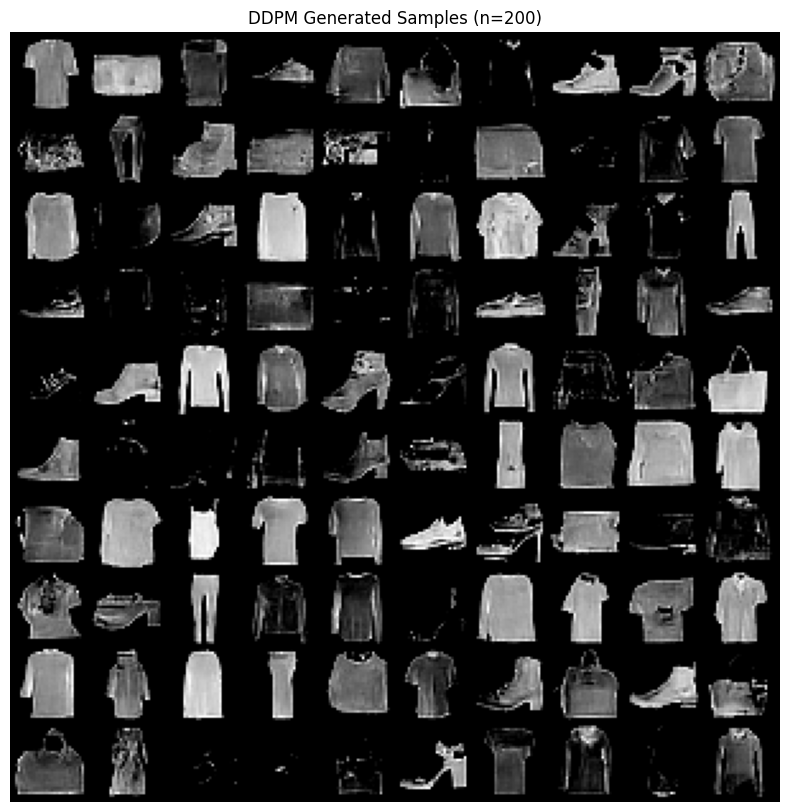

In [8]:
@torch.no_grad()
def sample_ddpm(model, n_samples=200, folder="evaluation"):
    model.eval()
    img = torch.randn((n_samples, 1, 28, 28), device=device)
    
    print(f"Начинаем процесс обратной диффузии для {n_samples} образцов...")
    
    # От шага T-1 обратно к 0
    for i in reversed(range(0, T)):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        
        # Предсказываем шум с помощью UNet
        predicted_noise = model(img, t)
        
        # Коэффициенты для текущего шага
        alpha = get_index_from_list(alphas, t, img.shape)
        alpha_cumprod = get_index_from_list(alphas_cumprod, t, img.shape)
        beta = get_index_from_list(betas, t, img.shape)
        
        # Формула обратного шага DDPM
        if i > 0:
            noise = torch.randn_like(img)
        else:
            noise = 0
            
        # x_{t-1} = 1/sqrt(alpha) * (x_t - (1-alpha)/sqrt(1-alpha_cumprod) * pred_noise) + sigma * noise
        img = 1 / torch.sqrt(alpha) * (img - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * predicted_noise) + torch.sqrt(beta) * noise
        
        if (i+1) % 100 == 0:
            print(f"Шаг {i+1}/{T} завершен...")

    # Ограничиваем значения пикселей [0, 1]
    img = torch.clamp(img, 0, 1).cpu()
    
    # Сохраняем результат
    torch.save(img, f"{folder}/ddpm_samples.pt")
    
    # Визуализация 
    grid = torchvision.utils.make_grid(img[:100], nrow=10, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0), cmap='gray')
    plt.title(f"DDPM Generated Samples (n={n_samples})")
    plt.axis('off')
    plt.show()
    
    return img

# Генерация
ddpm_samples = sample_ddpm(diffusion_model)

In [11]:
def evaluate_models_strict(judge, folder="evaluation"):
    judge.eval()

    vae_samples = torch.load(f"{folder}/vae_samples.pt").to(device)
    ddpm_samples = torch.load(f"{folder}/ddpm_samples.pt").to(device)
    
    results = {}
    
    for name, samples in [("VAE", vae_samples), ("DDPM", ddpm_samples)]:
        with torch.no_grad():
            # Сэмплы обратно в [-1, 1] 
            samples_for_judge = (samples * 2) - 1
            
            # Получаем предсказания
            outputs = judge(samples_for_judge)
            probs = F.softmax(outputs, dim=1)
            confidences, _ = torch.max(probs, dim=1)
            
            avg_conf = confidences.mean().item()
            high_conf_share = (confidences > 0.8).float().mean().item()
            
            results[name] = {
                "avg_confidence": avg_conf,
                "high_confidence_share": high_conf_share
            }
            
    # Вывод результатов
    print(f"{'Модель':<10} | {'Средняя уверенность':<20} | {'Доля качественных (>0.8)':<25}")
    print("-" * 65)
    for name, metrics in results.items():
        print(f"{name:<10} | {metrics['avg_confidence']:18.4f} | {metrics['high_confidence_share']:23.4f}")
    
    return results

comparison_results = evaluate_models_strict(judge_model)

Модель     | Средняя уверенность  | Доля качественных (>0.8) 
-----------------------------------------------------------------
VAE        |             0.7333 |                  0.4600
DDPM       |             0.7932 |                  0.5650


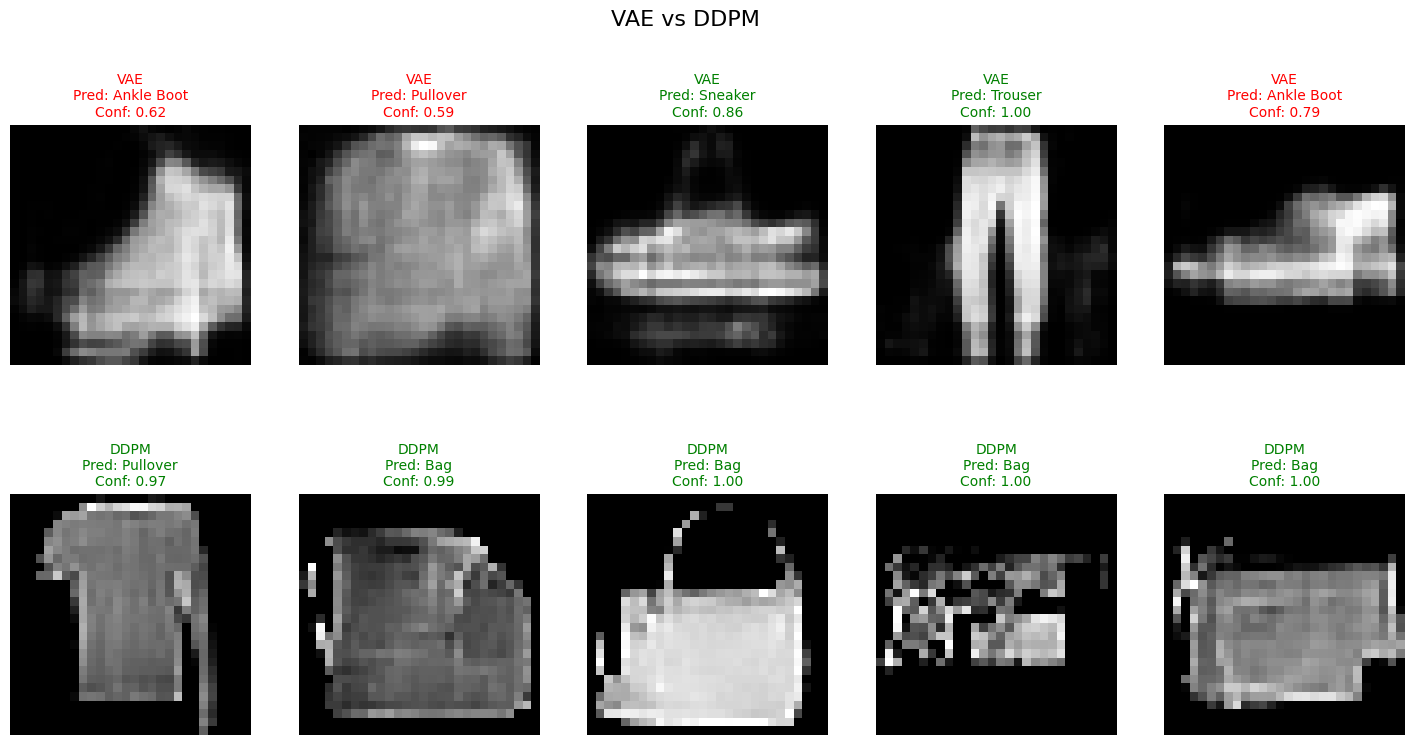

In [13]:
def visual_duel(judge, folder="evaluation", n_examples=5):
    judge.eval()
    
    # Названия классов Fashion-MNIST для подписей
    classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
    
    vae_samples = torch.load(f"{folder}/vae_samples.pt").to(device)
    ddpm_samples = torch.load(f"{folder}/ddpm_samples.pt").to(device)
    
    indices = torch.randint(0, len(vae_samples), (n_examples,))
    
    fig, axes = plt.subplots(2, n_examples, figsize=(18, 8))
    plt.subplots_adjust(hspace=0.5)

    for i, idx in enumerate(indices):
        for row, (name, data) in enumerate([("VAE", vae_samples), ("DDPM", ddpm_samples)]):
            img = data[idx].unsqueeze(0) 
            
            # Предсказание 
            with torch.no_grad():
                output = judge((img * 2) - 1)
                prob = F.softmax(output, dim=1)
                conf, pred = torch.max(prob, dim=1)
            
            # Отрисовка
            ax = axes[row, i]
            ax.imshow(img.squeeze().cpu().numpy(), cmap='gray')
            
            color = 'green' if conf.item() > 0.8 else 'red'
            
            ax.set_title(f"{name}\nPred: {classes[pred.item()]}\nConf: {conf.item():.2f}", 
                         fontsize=10, color=color)
            ax.axis('off')

    plt.suptitle("VAE vs DDPM", fontsize=16, y=1.02)
    plt.show()

visual_duel(judge_model)